# Домашнее задание. Основы машинного обучения

**Задача**: предсказать, выживет ли персонаж из Игры Престолов (`isAlive`).

**Метрика**: Accuracy

## Часть 1. Анализ и предобработка данных

### Задание 1.1. Импорт библиотек

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42

### Загрузка данных

In [2]:
os.makedirs('data', exist_ok=True)

gdown.download(id='1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v', output='data/game_of_thrones_train.csv', quiet=False)
gdown.download(id='1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3', output='data/game_of_thrones_test.csv', quiet=False)
gdown.download(id='1M14conWjAW2QLoyCXbHEAy8bql2f99eF', output='data/submission.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_train.csv



  0%|          | 0.00/138k [00:00<?, ?B/s]


100%|██████████| 138k/138k [00:00<00:00, 441kB/s]


100%|██████████| 138k/138k [00:00<00:00, 438kB/s]

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/game_of_thrones_test.csv


...


100%|██████████| 37.3k/37.3k [00:00<00:00, 309kB/s]

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /Users/yarkiy/Documents/GitHub/MFTI/4.1 Домашнее задание. Основы машинного обучения/data/submission.csv



  0%|          | 0.00/2.74k [00:00<?, ?B/s]


100%|██████████| 2.74k/2.74k [00:00<00:00, 5.55MB/s]

'data/submission.csv'

### Задание 1.2. Загрузка датасета в DataFrame

In [3]:
data = pd.read_csv('data/game_of_thrones_train.csv', index_col='S.No')
data_test = pd.read_csv('data/game_of_thrones_test.csv', index_col='S.No')

print(f'Train: {data.shape}')
print(f'Test: {data_test.shape}')
data.head()

Train: (1557, 25)
Test: (389, 24)


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   str    
 1   title             717 non-null    str    
 2   male              1557 non-null   int64  
 3   culture           488 non-null    str    
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     str    
 6   father            22 non-null     str    
 7   heir              21 non-null     str    
 8   house             1176 non-null   str    
 9   spouse            200 non-null    str    
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  isAliv

In [5]:
# Статистика по категориальным признакам
data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Viserys II Targaryen,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [6]:
# Статистика по числовым признакам — проверяем адекватность значений
data.describe(include=[np.number]).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


### Задание 1.3. Анализ пропущенных значений

Удалять строки с NaN не будем — слишком много пропусков.

In [7]:
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(1)
pd.DataFrame({'Пропуски': missing, '%': missing_pct}).query('Пропуски > 0').sort_values('%', ascending=False)

,Пропуски,%
mother,1539,98.8
isAliveMother,1539,98.8
heir,1536,98.7
isAliveHeir,1536,98.7
father,1535,98.6
isAliveFather,1535,98.6
spouse,1357,87.2
isAliveSpouse,1357,87.2
dateOfBirth,1278,82.1
age,1278,82.1


**Выводы по пропускам:**
- `mother`, `father`, `heir`, `isAliveMother/Father/Heir` — 98%+ пропусков → **удаляем**
- `spouse`, `isAliveSpouse` — 87% пропусков → обработаем по аналогии с age
- `dateOfBirth`, `age` — 82% пропусков → `age_value` + `age_no_data`
- `culture` — 69% пропусков → **группируем** по словарю, one-hot
- `title` — 54% пропусков → **удаляем** (высокая кардинальность)
- `house` — 25% пропусков → **удаляем** (315 уникальных значений)

**КРИТИЧНО**: `dateOfDeath` (если присутствует) — data leakage, удаляем обязательно!

### Задание 1.4. Визуализация числовых признаков

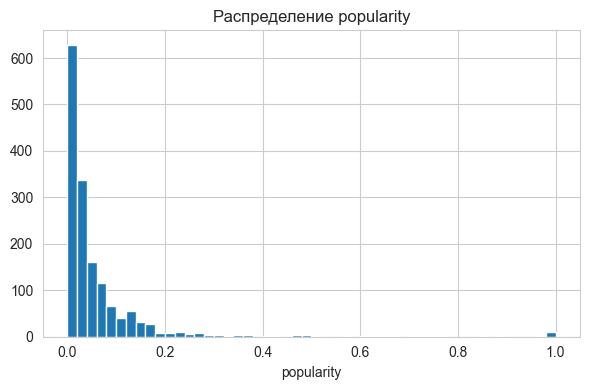

Popularity: min=0.0000, max=1.0000


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
data['popularity'].hist(bins=50, ax=ax)
ax.set_title('Распределение popularity')
ax.set_xlabel('popularity')
plt.tight_layout()
plt.show()

print(f"Popularity: min={data['popularity'].min():.4f}, max={data['popularity'].max():.4f}")

Распределение сильно скошено вправо. Применяем логарифмическое преобразование: `np.log10(popularity * M + 1)` с M=100.

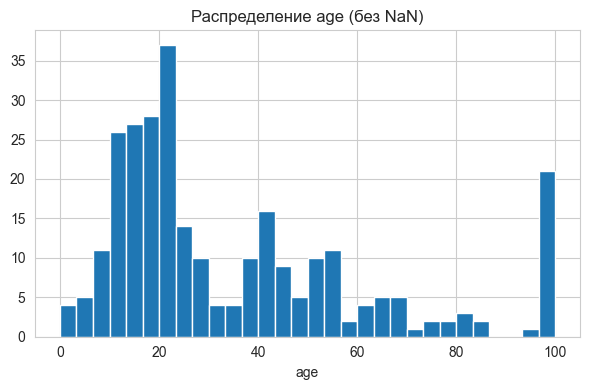

Age: заполнено 279 из 1557 (17.9%)


In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
data['age'].dropna().hist(bins=30, ax=ax)
ax.set_title('Распределение age (без NaN)')
ax.set_xlabel('age')
plt.tight_layout()
plt.show()

print(f"Age: заполнено {data['age'].notna().sum()} из {len(data)} ({data['age'].notna().mean()*100:.1f}%)")

In [10]:
print('Распределение numDeadRelations:')
print(data['numDeadRelations'].value_counts().sort_index())

Распределение numDeadRelations:
numDeadRelations
0     1488
1       24
2        4
3        4
4        7
5       10
6        3
7        7
8        2
9        1
10       4
11       1
12       1
15       1
Name: count, dtype: int64


### Задание 1.5. Предобработка данных

Оформляем предобработку как **функцию**, чтобы одинаково применить к train и test.

In [11]:
# Словарь группировки народов из задания
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']
}

# Инвертируем словарь для маппинга
cultures_grouped_inverted = {}
for k in cultures_grouped.keys():
    for v in cultures_grouped[k]:
        cultures_grouped_inverted.update({v: k})

print(f'Словарь маппинга: {len(cultures_grouped_inverted)} значений → {len(cultures_grouped)} групп')

Словарь маппинга: 59 значений → 11 групп


In [12]:
def preprocess(df, is_test=False):
    """
    Единый pipeline предобработки для train и test данных.
    
    Параметры:
        df: исходный DataFrame
        is_test: True для тестовых данных (нет колонки isAlive)
    
    Возвращает:
        DataFrame с обработанными признаками (без текстовых колонок)
    """
    d = df.copy()
    
    # --- Исправление ошибок в тестовых данных ---
    if is_test:
        if 1685 in d.index:
            d.loc[1685, 'dateOfBirth'] = 278.
            d.loc[1685, 'age'] = 0.
        if 1869 in d.index:
            d.loc[1869, 'dateOfBirth'] = 299.
            d.loc[1869, 'age'] = 0.
    
    # --- Удаление data leakage и бесполезных признаков ---
    # dateOfDeath — почти полностью повторяет целевую переменную!
    leak_cols = ['dateOfDeath', 'DateoFdeath']
    for col in leak_cols:
        if col in d.columns:
            d.drop(columns=[col], inplace=True)
            print(f'  УДАЛЁН data leakage: {col}')
    
    # Текстовые / высококардинальные признаки — удаляем
    drop_cols = ['name', 'title', 'house', 'spouse', 'father', 'mother', 'heir']
    drop_cols = [c for c in drop_cols if c in d.columns]
    d.drop(columns=drop_cols, inplace=True)
    
    # Признаки с 98%+ пропусков — бесполезны
    drop_sparse = ['isAliveMother', 'isAliveFather', 'isAliveHeir']
    drop_sparse = [c for c in drop_sparse if c in d.columns]
    d.drop(columns=drop_sparse, inplace=True)
    
    # --- Popularity: log-трансформация ---
    M = 100
    d['popularity_log'] = np.log10(d['popularity'] * M + 1)
    d.drop(columns=['popularity'], inplace=True)
    
    # --- numDeadRelations: бинарный признак ---
    d['boolDeadRelations'] = (d['numDeadRelations'] > 0).astype(int)
    
    # --- Age: разбиваем на значение и индикатор пропуска ---
    d['age_value'] = d['age'].fillna(0)
    d['age_no_data'] = [1 if np.isnan(x) else 0 for x in d['age']]
    d.drop(columns=['age'], inplace=True)
    
    # dateOfBirth — коллинеарен с age_no_data, удаляем
    if 'dateOfBirth' in d.columns:
        d.drop(columns=['dateOfBirth'], inplace=True)
    
    # --- isAliveSpouse: значение + индикатор наличия данных ---
    d['spouse_alive_value'] = d['isAliveSpouse'].fillna(0).astype(int)
    d['spouse_alive_known'] = d['isAliveSpouse'].notna().astype(int)
    d.drop(columns=['isAliveSpouse'], inplace=True)
    
    # --- Culture: группировка и one-hot кодирование ---
    d['culture_grouped'] = d['culture'].str.lower().str.strip().map(cultures_grouped_inverted)
    d['culture_grouped'] = d['culture_grouped'].fillna('culture_no_data')
    d.drop(columns=['culture'], inplace=True)
    
    # One-hot кодирование culture_grouped
    culture_dummies = pd.get_dummies(d['culture_grouped'], prefix='cult', dtype=int)
    d = pd.concat([d.drop(columns=['culture_grouped']), culture_dummies], axis=1)
    
    return d

print('Функция preprocess() определена')

Функция preprocess() определена


In [13]:
# Применяем предобработку
print('=== Обработка TRAIN ===')
train_processed = preprocess(data, is_test=False)
print(f'Размер после обработки: {train_processed.shape}')

print('\n=== Обработка TEST ===')
test_processed = preprocess(data_test, is_test=True)
print(f'Размер после обработки: {test_processed.shape}')

# Выравниваем колонки test по train (исключая isAlive)
train_features = [c for c in train_processed.columns if c != 'isAlive']
for col in train_features:
    if col not in test_processed.columns:
        test_processed[col] = 0
# Убираем лишние колонки из test
extra_cols = [c for c in test_processed.columns if c not in train_features]
if extra_cols:
    print(f'Удалены лишние колонки из test: {extra_cols}')
    test_processed.drop(columns=extra_cols, inplace=True)

# Упорядочиваем колонки test как в train
test_processed = test_processed[train_features]

print(f'\nФинальные признаки ({len(train_features)}):')
print(train_features)
print(f'\nNaN в train: {train_processed[train_features].isnull().sum().sum()}')
print(f'NaN в test: {test_processed.isnull().sum().sum()}')

=== Обработка TRAIN ===
Размер после обработки: (1557, 28)

=== Обработка TEST ===
Размер после обработки: (389, 27)

Финальные признаки (27):
['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'numDeadRelations', 'popularity_log', 'boolDeadRelations', 'age_value', 'age_no_data', 'spouse_alive_value', 'spouse_alive_known', 'cult_Dorne', 'cult_Essos Nations', 'cult_Old Nations', 'cult_Other Nations', 'cult_culture_no_data', 'cult_the Iron Islands', 'cult_the Isles and Rivers', 'cult_the Mountain and the Vale', 'cult_the North', 'cult_the Reach', 'cult_the Rock', 'cult_the Stormlands']

NaN в train: 0
NaN в test: 0


### Задание 1.5. Категориальные признаки — culture

In [14]:
# Распределение сгруппированных культур
culture_cols = [c for c in train_processed.columns if c.startswith('cult_')]
print('Распределение культур (train):')
print(train_processed[culture_cols].sum().sort_values(ascending=False))

Распределение культур (train):
cult_culture_no_data              1069
cult_Essos Nations                 109
cult_the North                     108
cult_the Iron Islands               95
cult_Other Nations                  57
cult_Old Nations                    32
cult_the Mountain and the Vale      25
cult_Dorne                          21
cult_the Rock                       14
cult_the Reach                      13
cult_the Isles and Rivers           10
cult_the Stormlands                  4
dtype: int64


### Задание 1.6. Количество уникальных значений

In [15]:
print('Количество уникальных значений по признакам:')
print(train_processed[train_features].nunique().sort_values())

Количество уникальных значений по признакам:
male                                2
cult_the Reach                      2
cult_the North                      2
cult_the Mountain and the Vale      2
cult_the Isles and Rivers           2
cult_the Iron Islands               2
cult_culture_no_data                2
cult_Other Nations                  2
cult_Old Nations                    2
cult_Essos Nations                  2
cult_Dorne                          2
spouse_alive_known                  2
cult_the Rock                       2
spouse_alive_value                  2
boolDeadRelations                   2
isNoble                             2
isMarried                           2
book5                               2
book4                               2
book3                               2
book2                               2
book1                               2
age_no_data                         2
cult_the Stormlands                 2
numDeadRelations                   14
age_v

### Задание 1.7-1.8. Влияние признаков на целевую переменную

Распределение isAlive:
isAlive
1    1212
0     345
Name: count, dtype: int64
Доля живых: 0.778


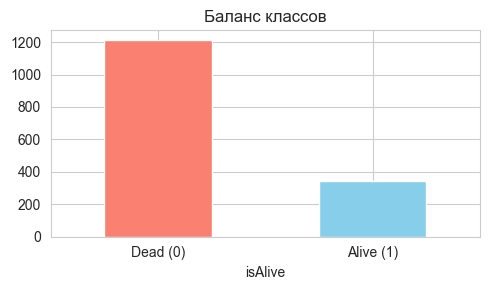

In [16]:
# Баланс целевой переменной
print('Распределение isAlive:')
print(data['isAlive'].value_counts())
print(f'Доля живых: {data["isAlive"].mean():.3f}')

fig, ax = plt.subplots(figsize=(5, 3))
data['isAlive'].value_counts().plot(kind='bar', ax=ax, color=['salmon', 'skyblue'])
ax.set_title('Баланс классов')
ax.set_xticklabels(['Dead (0)', 'Alive (1)'], rotation=0)
plt.tight_layout()
plt.show()

Корреляция признаков с isAlive:
book4                    0.284014
popularity_log          -0.242497
numDeadRelations        -0.198876
age_value               -0.181938
boolDeadRelations       -0.178177
cult_Old Nations        -0.173409
male                    -0.148290
age_no_data              0.113629
book1                   -0.112468
cult_the Iron Islands    0.064933
cult_the Rock           -0.063857
isNoble                 -0.060572
book2                   -0.055998
spouse_alive_known      -0.049381
isMarried               -0.049381
Name: isAlive, dtype: float64


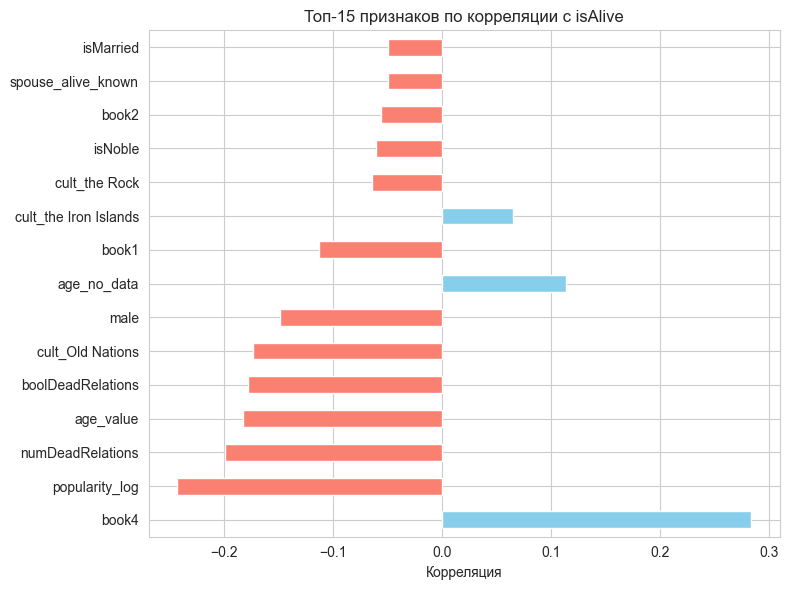

In [17]:
# Корреляция числовых признаков с isAlive
corr_with_target = train_processed.corr()['isAlive'].drop('isAlive').sort_values(key=abs, ascending=False)
print('Корреляция признаков с isAlive:')
print(corr_with_target.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.head(15).plot(
    kind='barh', ax=ax,
    color=['salmon' if v < 0 else 'skyblue' for v in corr_with_target.head(15)]
)
ax.set_title('Топ-15 признаков по корреляции с isAlive')
ax.set_xlabel('Корреляция')
plt.tight_layout()
plt.show()

In [18]:
# Сравнение средних isAlive для бинарных признаков
binary_cols = ['male', 'book1', 'book2', 'book3', 'book4', 'book5',
               'isMarried', 'isNoble', 'boolDeadRelations', 'age_no_data',
               'spouse_alive_known']

for col in binary_cols:
    alive_rate = train_processed.groupby(col)['isAlive'].mean()
    print(f'{col}: 0 -> {alive_rate[0]:.3f}, 1 -> {alive_rate[1]:.3f} (разница {abs(alive_rate[1]-alive_rate[0]):.3f})')

male: 0 -> 0.852, 1 -> 0.727 (разница 0.125)
book1: 0 -> 0.797, 1 -> 0.662 (разница 0.135)
book2: 0 -> 0.795, 1 -> 0.745 (разница 0.050)
book3: 0 -> 0.772, 1 -> 0.787 (разница 0.015)
book4: 0 -> 0.645, 1 -> 0.882 (разница 0.238)
book5: 0 -> 0.769, 1 -> 0.798 (разница 0.029)
isMarried: 0 -> 0.786, 1 -> 0.725 (разница 0.061)
isNoble: 0 -> 0.801, 1 -> 0.750 (разница 0.051)
boolDeadRelations: 0 -> 0.794, 1 -> 0.435 (разница 0.360)
age_no_data: 0 -> 0.677, 1 -> 0.800 (разница 0.123)
spouse_alive_known: 0 -> 0.786, 1 -> 0.725 (разница 0.061)


**Самые информативные признаки:**
- `boolDeadRelations`: наличие мёртвых родственников сильно снижает шансы выжить
- `book4`: появление в 4-й книге повышает шансы выживания
- `popularity_log`: популярные персонажи чаще погибают
- `male`: мужчины выживают реже
- `age_no_data`: персонажи без указанного возраста чаще живы

### Задание 1.9-1.10. Формирование X, y и разделение на train/val

In [19]:
# Формируем X и y
X = train_processed[train_features].values
y = train_processed['isAlive'].values
X_test_final = test_processed.values

print(f'X: {X.shape}, y: {y.shape}')
print(f'X_test: {X_test_final.shape}')
print(f'NaN: X={np.isnan(X).sum()}, X_test={np.isnan(X_test_final).sum()}')

X: (1557, 27), y: (1557,)
X_test: (389, 27)
NaN: X=0, X_test=0


In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'X_train: {X_train.shape}, X_val: {X_val.shape}')
print(f'Баланс классов train: {np.mean(y_train):.3f}')
print(f'Баланс классов val:   {np.mean(y_val):.3f}')

X_train: (1245, 27), X_val: (312, 27)
Баланс классов train: 0.778
Баланс классов val:   0.779


## Часть 2. Обучение моделей

### Задание 2.1-2.2. Обучение нескольких моделей

Обучаем модели из рекомендованного списка:
1. **LogisticRegression** — основная
2. **RandomForestClassifier** — ансамбль деревьев
3. **KNeighborsClassifier** — метод ближайших соседей
4. **DecisionTreeClassifier** — дерево решений

Используем `Pipeline(StandardScaler + модель)` для корректного масштабирования.

In [ ]:
# Модель 1: Logistic Regression
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver='liblinear'))
])

pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_val)
acc_lr = accuracy_score(y_val, y_pred_lr)
print(f'Logistic Regression Accuracy (val): {acc_lr:.4f}')

Logistic Regression Accuracy (val): 0.7724


In [ ]:
# Модель 2: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
print(f'Random Forest Accuracy (val): {acc_rf:.4f}')

Random Forest Accuracy (val): 0.7853


In [ ]:
# Модель 3: KNN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=15))
])

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_val)
acc_knn = accuracy_score(y_val, y_pred_knn)
print(f'KNN (k=15) Accuracy (val): {acc_knn:.4f}')

KNN (k=15) Accuracy (val): 0.7724


In [ ]:
# Модель 4: Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_val)
acc_dt = accuracy_score(y_val, y_pred_dt)
print(f'Decision Tree Accuracy (val): {acc_dt:.4f}')

Decision Tree Accuracy (val): 0.7853


             Модель  Accuracy (val)
      Random Forest        0.785256
      Decision Tree        0.785256
Logistic Regression        0.772436
         KNN (k=15)        0.772436


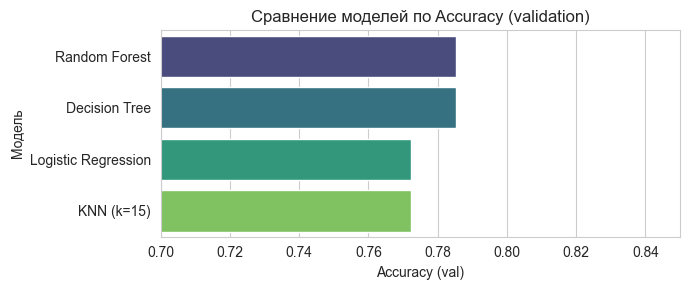

In [ ]:
# Сравнение моделей (простая оценка на val)
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Random Forest', 'KNN (k=15)', 'Decision Tree'],
    'Accuracy (val)': [acc_lr, acc_rf, acc_knn, acc_dt]
}).sort_values('Accuracy (val)', ascending=False).reset_index(drop=True)

print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3))
sns.barplot(data=results, x='Accuracy (val)', y='Модель', ax=ax, palette='viridis')
ax.set_title('Сравнение моделей по Accuracy (validation)')
ax.set_xlim(0.7, 0.85)
plt.tight_layout()
plt.show()

### Подбор гиперпараметров через кросс-валидацию

Используем 10-fold CV с Pipeline внутри GridSearchCV.

In [ ]:
# GridSearch для LogReg с Pipeline
pipe_lr_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver='liblinear'))
])

param_grid_lr = {
    'lr__C': [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 5.0, 10.0],
    'lr__penalty': ['l1', 'l2'],
}

grid_lr = GridSearchCV(pipe_lr_cv, param_grid_lr, cv=10, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X, y)

print(f'LogReg лучшие параметры: {grid_lr.best_params_}')
print(f'LogReg лучший CV-10 Accuracy: {grid_lr.best_score_:.4f}')

LogReg лучшие параметры: {'lr__C': 0.01, 'lr__penalty': 'l2'}
LogReg лучший CV-10 Accuracy: 0.8060


In [ ]:
# GridSearch для Random Forest
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_leaf': [3, 5, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid_rf, cv=10, scoring='accuracy', n_jobs=-1
)
grid_rf.fit(X, y)

print(f'RF лучшие параметры: {grid_rf.best_params_}')
print(f'RF лучший CV-10 Accuracy: {grid_rf.best_score_:.4f}')

RF лучшие параметры: {'max_depth': 7, 'min_samples_leaf': 3, 'n_estimators': 100}
RF лучший CV-10 Accuracy: 0.8137


In [ ]:
# GridSearch для KNN с Pipeline
pipe_knn_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {'knn__n_neighbors': [5, 7, 9, 11, 13, 15, 17, 21, 25, 31]}

grid_knn = GridSearchCV(pipe_knn_cv, param_grid_knn, cv=10, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X, y)

print(f'KNN лучшие параметры: {grid_knn.best_params_}')
print(f'KNN лучший CV-10 Accuracy: {grid_knn.best_score_:.4f}')

KNN лучшие параметры: {'knn__n_neighbors': 31}
KNN лучший CV-10 Accuracy: 0.8105


In [ ]:
# GridSearch для Decision Tree
param_grid_dt = {'max_depth': [2, 3, 4, 5, 6, 7, 8]}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid_dt, cv=10, scoring='accuracy', n_jobs=-1
)
grid_dt.fit(X, y)

print(f'DT лучшие параметры: {grid_dt.best_params_}')
print(f'DT лучший CV-10 Accuracy: {grid_dt.best_score_:.4f}')

DT лучшие параметры: {'max_depth': 5}
DT лучший CV-10 Accuracy: 0.8079


In [ ]:
# Сводная таблица CV результатов
cv_results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'Random Forest', 'KNN', 'Decision Tree'],
    'Лучшие параметры': [
        str(grid_lr.best_params_), str(grid_rf.best_params_),
        str(grid_knn.best_params_), str(grid_dt.best_params_)
    ],
    'CV-10 Accuracy': [
        grid_lr.best_score_, grid_rf.best_score_,
        grid_knn.best_score_, grid_dt.best_score_
    ]
}).sort_values('CV-10 Accuracy', ascending=False).reset_index(drop=True)

print('=== Результаты кросс-валидации ===')
print(cv_results.to_string(index=False))

# Выбираем лучшую модель по CV
all_grids = {
    'Logistic Regression': grid_lr,
    'Random Forest': grid_rf,
    'KNN': grid_knn,
    'Decision Tree': grid_dt
}

best_name = cv_results.iloc[0]['Модель']
best_grid = all_grids[best_name]
best_model = best_grid.best_estimator_
best_cv = best_grid.best_score_

print(f'\nФинальная модель: {best_name}')
print(f'CV-10 Accuracy: {best_cv:.4f}')

=== Результаты кросс-валидации ===
             Модель                                             Лучшие параметры  CV-10 Accuracy
      Random Forest {'max_depth': 7, 'min_samples_leaf': 3, 'n_estimators': 100}        0.813718
                KNN                                     {'knn__n_neighbors': 31}        0.810500
      Decision Tree                                             {'max_depth': 5}        0.807945
Logistic Regression                         {'lr__C': 0.01, 'lr__penalty': 'l2'}        0.806026

Финальная модель: Random Forest
CV-10 Accuracy: 0.8137


## Часть 3. Оценка качества

### Задание 3.1. Метрики лучшей модели

In [31]:
# Оценка лучшей модели на валидационной выборке
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_val)

print(f'Accuracy на валидации: {accuracy_score(y_val, y_pred_best):.4f}')
print()
print('Classification Report:')
print(classification_report(y_val, y_pred_best, target_names=['Dead (0)', 'Alive (1)']))

Accuracy на валидации: 0.8013

Classification Report:
              precision    recall  f1-score   support

    Dead (0)       0.68      0.19      0.30        69
   Alive (1)       0.81      0.98      0.88       243

    accuracy                           0.80       312
   macro avg       0.75      0.58      0.59       312
weighted avg       0.78      0.80      0.75       312



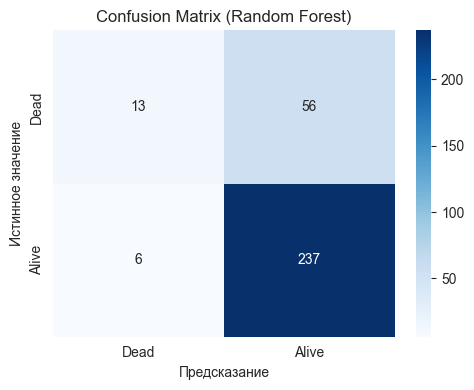

In [32]:
cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Dead', 'Alive'], yticklabels=['Dead', 'Alive'])
ax.set_xlabel('Предсказание')
ax.set_ylabel('Истинное значение')
ax.set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout()
plt.show()

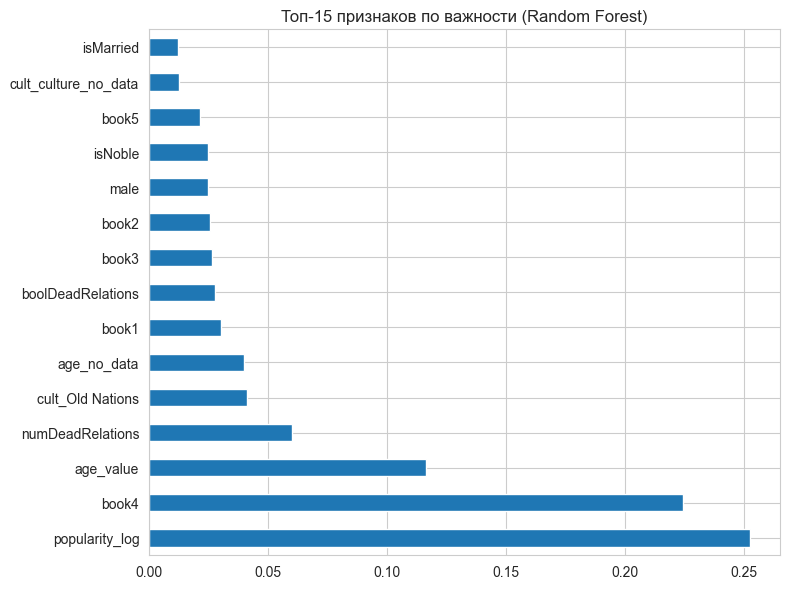

Важность признаков:
             popularity_log: 0.2524
                      book4: 0.2243
                  age_value: 0.1164
           numDeadRelations: 0.0600
           cult_Old Nations: 0.0411
                age_no_data: 0.0401
                      book1: 0.0303
          boolDeadRelations: 0.0276
                      book3: 0.0265
                      book2: 0.0257
                       male: 0.0249
                    isNoble: 0.0247
                      book5: 0.0215
       cult_culture_no_data: 0.0126
                  isMarried: 0.0123
              cult_the Rock: 0.0116
         spouse_alive_known: 0.0115
         cult_Other Nations: 0.0102
         spouse_alive_value: 0.0075
             cult_the North: 0.0073
      cult_the Iron Islands: 0.0055
         cult_Essos Nations: 0.0034
  cult_the Mountain and the Vale: 0.0010
  cult_the Isles and Rivers: 0.0008
                 cult_Dorne: 0.0008
             cult_the Reach: 0.0001
        cult_the Stormlands: 0.0001


In [33]:
# Важность признаков
if hasattr(best_model, 'feature_importances_'):
    # Для деревьев / ансамблей
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=train_features).sort_values(ascending=False)
elif hasattr(best_model, 'named_steps'):
    # Для Pipeline с LogReg
    lr_model = best_model.named_steps.get('lr', None)
    if lr_model is not None and hasattr(lr_model, 'coef_'):
        importances = np.abs(lr_model.coef_[0])
        feat_imp = pd.Series(importances, index=train_features).sort_values(ascending=False)
    else:
        feat_imp = None
else:
    feat_imp = None

if feat_imp is not None:
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp.head(15).plot(kind='barh', ax=ax)
    ax.set_title(f'Топ-15 признаков по важности ({best_name})')
    plt.tight_layout()
    plt.show()
    
    print('Важность признаков:')
    for feat, imp in feat_imp.items():
        print(f'  {feat:>25s}: {imp:.4f}')
else:
    print(f'Модель {best_name} не поддерживает анализ важности признаков')

### Финальное обучение и предсказание на тестовых данных

In [34]:
# Обучаем лучшую модель на ВСЁМ train
best_model.fit(X, y)
y_test_pred = best_model.predict(X_test_final)

print(f'Распределение предсказаний: 0={sum(y_test_pred==0)}, 1={sum(y_test_pred==1)}')
print(f'Доля предсказанных "alive": {np.mean(y_test_pred):.3f}')
print(f'Доля "alive" в train: {np.mean(y):.3f}')

Распределение предсказаний: 0=47, 1=342
Доля предсказанных "alive": 0.879
Доля "alive" в train: 0.778


### Генерация submission.csv

In [35]:
submission = pd.read_csv('data/submission.csv')
submission['isAlive'] = y_test_pred
submission.to_csv('submission.csv', index=False)

print(f'submission.csv создан: {submission.shape}')
print(submission.head(10))
print(f'\nРаспределение предсказаний:')
print(submission['isAlive'].value_counts())
print(f'\nAccuracy (CV-10): {best_cv:.4f}')
print(f'Модель: {best_name}')

submission.csv создан: (389, 2)
   S.No  isAlive
0  1558        0
1  1559        1
2  1560        1
3  1561        1
4  1562        1
5  1563        1
6  1564        1
7  1565        1
8  1566        1
9  1567        1

Распределение предсказаний:
isAlive
1    342
0     47
Name: count, dtype: int64

Accuracy (CV-10): 0.8137
Модель: Random Forest
